In [1]:
import os
import json
import sys
sys.path.append(r'C:\Users\Arthur Zhou\GitHub\aps360_project\src')
import matplotlib


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from train.train_utils import safe_pearson, safe_spearman

#pd.set_option('display.float_format', lambda x: f'{x:.4f}')


### Zero-shot scoring: log P(mutant | structure) - log P(WT | structure) vs measured DMS fitness




In [2]:
def load_zero_shot_results(output_dir):
    results_df = pd.read_csv(os.path.join(output_dir, "zero_shot_predictions.csv"))
    with open(os.path.join(output_dir, "zero_shot_summary.json")) as f:
        summary = json.load(f)
    return results_df, summary


def spearman_pearson(df, score_col="zero_shot_score") -> dict:
    return {
        "n": len(df),
        "Pearson_r": safe_pearson(df["Fitness"], df[score_col]),
        "Spearman_rho": safe_spearman(df["Fitness"], df[score_col]),
    }


def plot_zero_shot_scatter(results_df, score_col="zero_shot_score", xlabel="Zero-shot score: log P(mutant) - log P(WT)", title="", ax=None):
    """
    Score vs measured fitness. Single and pair mutants are shown separately since they
    come from two different DMS experiments (see compare_data.ipynb for the
    cross-experiment fitness disagreement between them).
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 5))

    singles = results_df[results_df["Single"] == 1]
    pairs = results_df[results_df["Single"] == 0]

    ax.scatter(singles[score_col].values, singles["Fitness"].values, alpha=0.4, s=3,
               edgecolor="none", label=f"single (n={len(singles)})", color="darkslateblue")
    if len(pairs):
        ax.scatter(pairs[score_col].values, pairs["Fitness"].values, alpha=0.4, s=3,
                   edgecolor="none", label=f"pair (n={len(pairs)})", color="darkred")

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Measured fitness")
    ax.set_title(title)
    ax.legend()
    print("here")
    return ax


In [ ]:
output_dir = "../src/train/gnn/output_pretrain/zero_shot"
results_df, summary = load_zero_shot_results(output_dir)

print(f"n_samples: {summary['n_samples']}")
print(f"Pearson r: {summary['pearson_r']:.4f}")
print(f"Spearman rho: {summary['spearman_rho']:.4f}")

results_df.head()


In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
plot_zero_shot_scatter(results_df, title=f"Zero-shot score vs fitness (n={summary['n_samples']})", ax=ax)
plt.tight_layout()
plt.savefig("zero_shot_scatter.png", dpi=200, bbox_inches="tight")
plt.show()


### Single vs pair mutants separately



In [ ]:
subset_metrics = {
    "single": spearman_pearson(results_df[results_df["Single"] == 1]),
    "pair": spearman_pearson(results_df[results_df["Single"] == 0]),
    "combined": spearman_pearson(results_df),
}
pd.DataFrame(subset_metrics).T


# View the PSSM

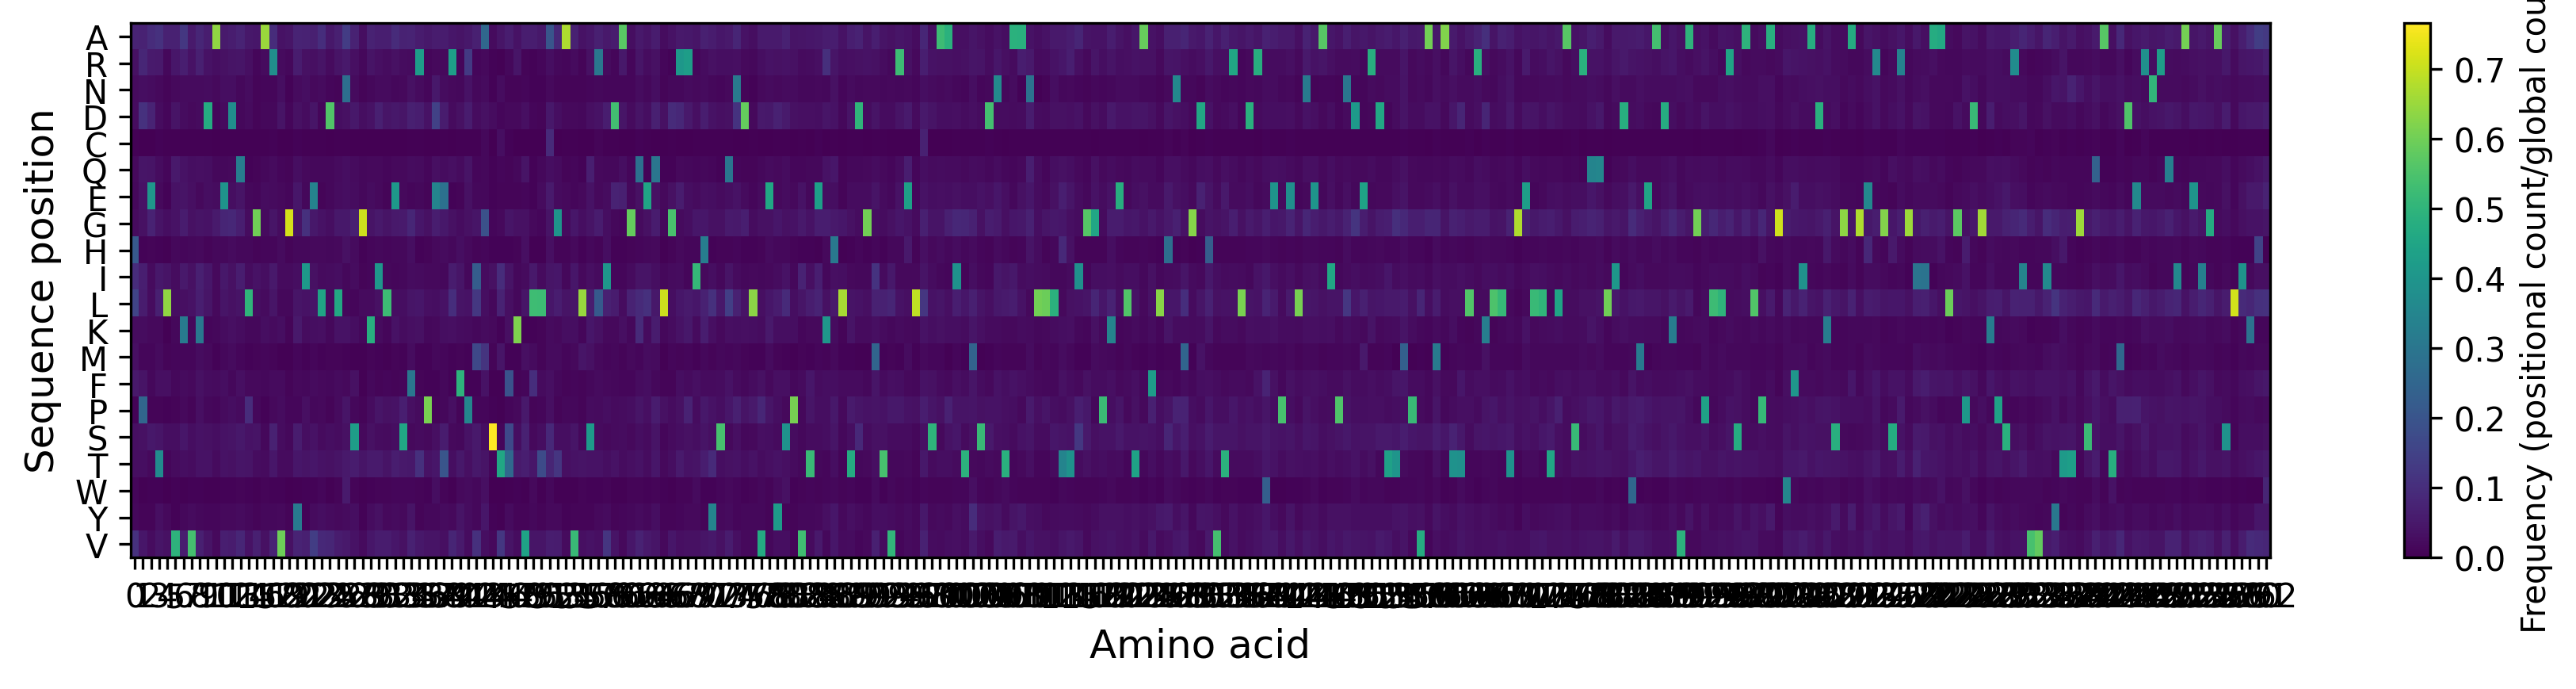

In [19]:
df = pd.read_csv(r'C:\Users\Arthur Zhou\GitHub\aps360_project\src\data\processed\homologs\pssm.csv')

aa_order = [
    "A","R","N","D","C","Q","E","G",
    "H","I","L","K","M","F","P","S",
    "T","W","Y","V"
]

pssm = df[aa_order].values
fig, ax = plt.subplots(figsize=(12, 3), dpi=300)

im = ax.imshow(
    pssm.T,
    aspect="auto",
    interpolation="nearest",
    vmin=0,
    vmax=np.max(pssm),
)

ax.set_xlabel("Amino acid", fontsize=12)
ax.set_ylabel("Sequence position", fontsize=12)

ax.set_yticks(np.arange(len(aa_order)))
ax.set_yticklabels(aa_order)

ax.set_xticks(np.arange(len(df)))
ax.set_xticklabels(df["wt_position"])

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Frequency (positional count/global count)")

plt.tight_layout()
plt.show()

### Evolutionary conservation baseline (heuristic, no learning at all)

Same scoring formula as the zero-shot GNN (`log freq(mutant) - log freq(WT)`), but the probability comes from raw per-position amino acid frequencies across the homolog family (a PSSM built by `pssm_process.py`)


here


C:\Users\Arthur Zhou\GitHub\aps360_project\src\train\train_utils.py:99: RuntimeWarning: Mean of empty slice.
  x_centered = x - x.mean()
c:\anaconda3\envs\mcx_env\lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\Arthur Zhou\GitHub\aps360_project\src\train\train_utils.py:100: RuntimeWarning: Mean of empty slice.
  y_centered = y - y.mean()


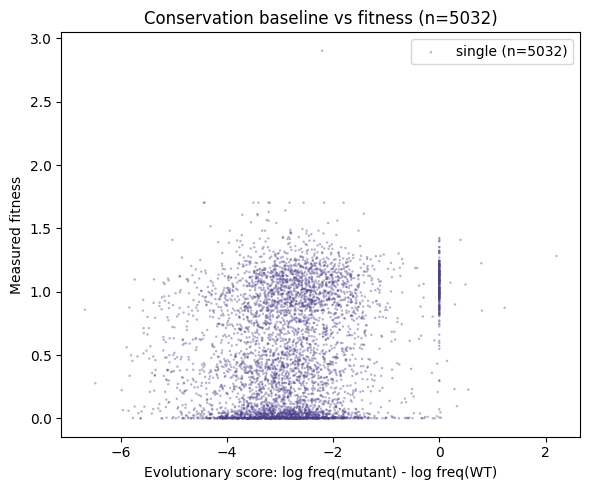

In [3]:
def load_evolutionary_results(output_dir):
    results_df = pd.read_csv(os.path.join(output_dir, "evolutionary_predictions.csv"))
    with open(os.path.join(output_dir, "evolutionary_summary.json")) as f:
        summary = json.load(f)
    return results_df, summary

evo_output_dir = "../src/train/evolutionary/output/inference"
evo_results_df, evo_summary = load_evolutionary_results(evo_output_dir)

evo_subset_metrics = {
    "single": spearman_pearson(evo_results_df[evo_results_df["Single"] == 1], score_col="evolutionary_score"),
    "pair": spearman_pearson(evo_results_df[evo_results_df["Single"] == 0], score_col="evolutionary_score"),
    "combined": spearman_pearson(evo_results_df, score_col="evolutionary_score"),
}

fig, ax = plt.subplots(figsize=(6, 5))
plot_zero_shot_scatter(evo_results_df, score_col="evolutionary_score",
                       xlabel="Evolutionary score: log freq(mutant) - log freq(WT)",
                       title=f"Conservation baseline vs fitness (n={evo_summary['n_samples']})", ax=ax)
plt.tight_layout()
plt.show()


### muitation scan and score (fitness vs pred)
`mutational_scan.py` scores all 263 x 19 = 4,997 possible single-residue substitutions from the PSSM: position along x, substituted-in amino acid along y.


In [12]:
AA_ORDER = ['G','A','V','L','I','M','F','W','P','C','S','T','N','Q','Y','H','D','E','K','R']

def load_mutational_scan(output_dir):
    return pd.read_csv(os.path.join(output_dir, "mutational_scan.csv"))


def build_grid(scan_df, value_col, aa_order=AA_ORDER):
    """
    Long-format (position, wt_aa, mut_aa, value) -> a (len(aa_order), n_positions) matrix,
    row = substituted-in amino acid (property-grouped, not alphabetical, so similar
    substitutions cluster visually), column = WT structure position. NaN where not
    applicable (WT-to-itself) or not measured.
    """
    n_positions = scan_df["position"].max() + 1
    grid = np.full((len(aa_order), n_positions), np.nan)
    row_of = {aa: i for i, aa in enumerate(aa_order)}
    for _, row in scan_df.iterrows():
        grid[row_of[row["mut_aa"]], row["position"]] = row[value_col]
    return grid


def plot_mutational_scan(scan_df, aa_order=AA_ORDER, cell_width=0.09, tick_every=20):
    """
    """
 
    predicted_grid = build_grid(scan_df, "predicted_score", aa_order)
    actual_grid = build_grid(scan_df, "actual_fitness", aa_order)
    n_positions = predicted_grid.shape[1]

    pred_half_range = np.nanmax(np.abs(predicted_grid))
    fitness_half_range = np.nanmax(np.abs(actual_grid - 1))
    predicted_norm = predicted_grid / pred_half_range
    actual_norm = (actual_grid - 1) / fitness_half_range

    wt_sequence = scan_df.groupby("position")["wt_aa"].first().sort_index().tolist()
    xtick_labels = [f"{aa}\n{pos}" if pos % tick_every == 0 else aa for pos, aa in enumerate(wt_sequence)]

    fig, axes = plt.subplots(2, 1, figsize=(max(12, n_positions * cell_width), 7), sharex=True)

    im0 = axes[0].imshow(predicted_norm, aspect="auto", cmap="RdBu", vmin=-1, vmax=1)
    axes[0].set_yticks(range(len(aa_order)))
    axes[0].set_yticklabels(aa_order, fontsize=8)
    axes[0].set_title("Predicted: log freq(mutant) - log freq(WT)")

    im1 = axes[1].imshow(actual_norm, aspect="auto", cmap="RdBu", vmin=-1, vmax=1)
    axes[1].set_yticks(range(len(aa_order)))
    axes[1].set_yticklabels(aa_order, fontsize=8)
    axes[1].set_title("Measured DMS fitness")

    axes[1].set_xticks(range(n_positions))
    axes[1].set_xticklabels(xtick_labels, fontsize=5)
    axes[1].set_xlabel("WT sequence")

    fig.colorbar(im0, ax=axes, fraction=0.015, pad=0.01,
                 label="Normalized effect")
# (-1 = most deleterious / lowest fitness, +1 = most tolerated / highest fitness)
    return fig, axes


n possible mutations: 4997, n measured: 4783
Pearson r: 0.1120, Spearman rho: 0.1267


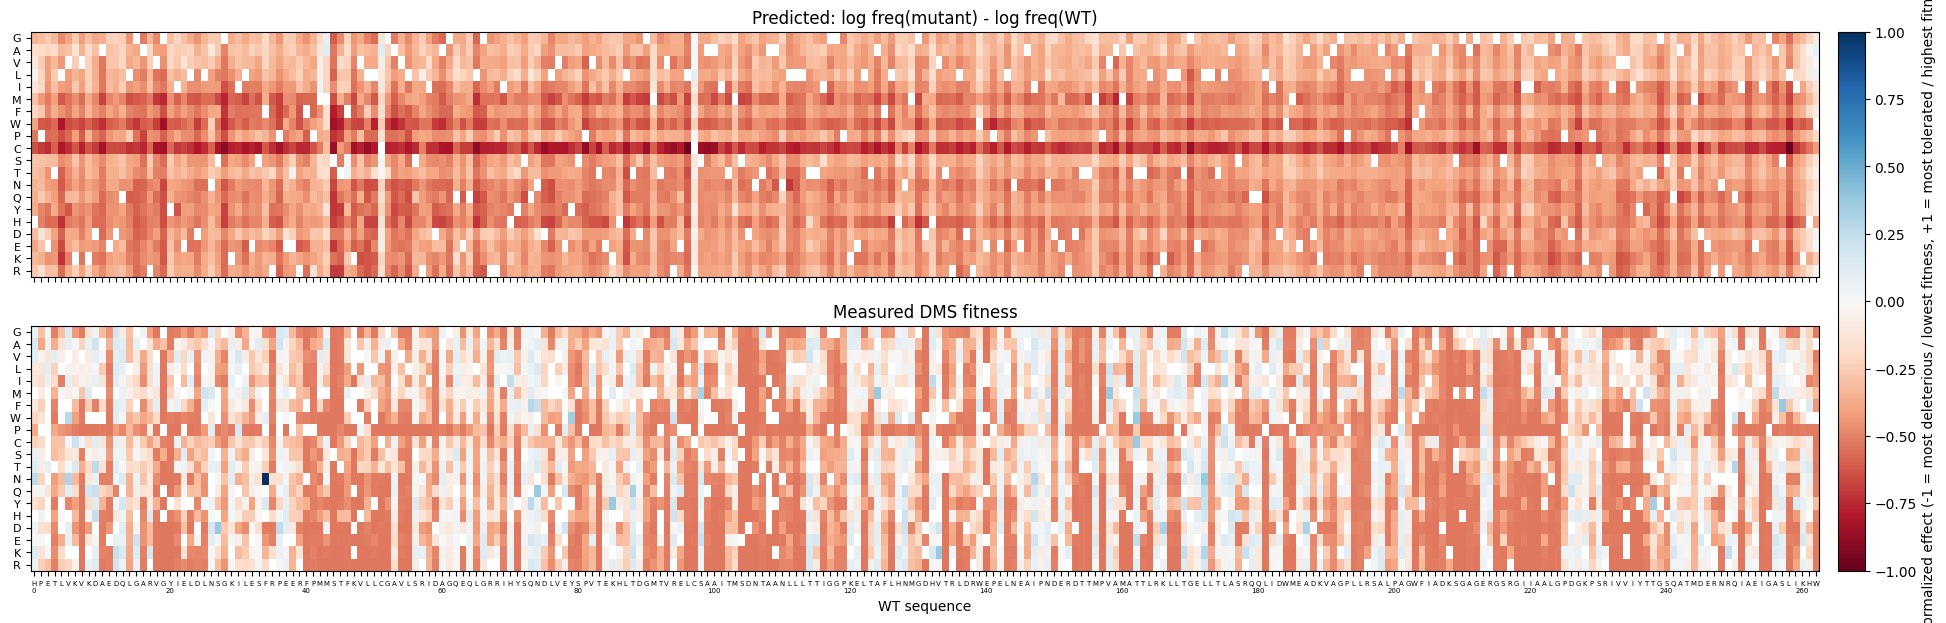

In [ ]:
scan_df = load_mutational_scan("../src/train/evolutionary/output/mutational_scan")

n_measured = scan_df["actual_fitness"].notna().sum()
scan_pearson = safe_pearson(scan_df.loc[scan_df["actual_fitness"].notna(), "predicted_score"],
                             scan_df.loc[scan_df["actual_fitness"].notna(), "actual_fitness"])
scan_spearman = safe_spearman(scan_df.loc[scan_df["actual_fitness"].notna(), "predicted_score"],
                               scan_df.loc[scan_df["actual_fitness"].notna(), "actual_fitness"])
print(f"n possible mutations: {len(scan_df)}, n measured: {n_measured}")
print(f"Pearson r: {scan_pearson:.4f}, Spearman rho: {scan_spearman:.4f}")

fig, axes = plot_mutational_scan(scan_df)
#plt.savefig("mutational_scan.png", dpi=200, bbox_inches="tight")
plt.show()
